In [151]:
# Task 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score

In [152]:
df=pd.read_csv('CarPrice_Assignment.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [153]:
df.drop('CarName',axis=1,inplace=True)
df.drop('car_ID',axis=1,inplace=True)
df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [154]:
encoder=LabelEncoder()
df['fueltype']=encoder.fit_transform(df['fueltype'])
df['aspiration']=encoder.fit_transform(df['aspiration'])
df['doornumber']=encoder.fit_transform(df['doornumber'])
df['carbody']=encoder.fit_transform(df['carbody'])
df['drivewheel']=encoder.fit_transform(df['drivewheel'])
df['enginelocation']=encoder.fit_transform(df['enginelocation'])
df['fuelsystem']=encoder.fit_transform(df['fuelsystem'])
df['enginetype']=encoder.fit_transform(df['enginetype'])
df['cylindernumber']=encoder.fit_transform(df['cylindernumber'])
df.head(n=10)

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,1,0,1,0,2,0,88.6,168.8,64.1,...,130,5,3.47,2.68,9.0,111,5000,21,27,13495.000
1,3,1,0,1,0,2,0,88.6,168.8,64.1,...,130,5,3.47,2.68,9.0,111,5000,21,27,16500.000
2,1,1,0,1,2,2,0,94.5,171.2,65.5,...,152,5,2.68,3.47,9.0,154,5000,19,26,16500.000
3,2,1,0,0,3,1,0,99.8,176.6,66.2,...,109,5,3.19,3.40,10.0,102,5500,24,30,13950.000
4,2,1,0,0,3,0,0,99.4,176.6,66.4,...,136,5,3.19,3.40,8.0,115,5500,18,22,17450.000
5,2,1,0,1,3,1,0,99.8,177.3,66.3,...,136,5,3.19,3.40,8.5,110,5500,19,25,15250.000
6,1,1,0,0,3,1,0,105.8,192.7,71.4,...,136,5,3.19,3.40,8.5,110,5500,19,25,17710.000
7,1,1,0,0,4,1,0,105.8,192.7,71.4,...,136,5,3.19,3.40,8.5,110,5500,19,25,18920.000
8,1,1,1,0,3,1,0,105.8,192.7,71.4,...,131,5,3.13,3.40,8.3,140,5500,17,20,23875.000
9,0,1,1,1,2,0,0,99.5,178.2,67.9,...,131,5,3.13,3.40,7.0,160,5500,16,22,17859.167


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   fueltype          205 non-null    int64  
 2   aspiration        205 non-null    int64  
 3   doornumber        205 non-null    int64  
 4   carbody           205 non-null    int64  
 5   drivewheel        205 non-null    int64  
 6   enginelocation    205 non-null    int64  
 7   wheelbase         205 non-null    float64
 8   carlength         205 non-null    float64
 9   carwidth          205 non-null    float64
 10  carheight         205 non-null    float64
 11  curbweight        205 non-null    int64  
 12  enginetype        205 non-null    int64  
 13  cylindernumber    205 non-null    int64  
 14  enginesize        205 non-null    int64  
 15  fuelsystem        205 non-null    int64  
 16  boreratio         205 non-null    float64
 1

In [156]:
df.describe()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,0.902439,0.180488,0.439024,2.614634,1.326829,0.014634,98.756585,174.049268,65.907805,...,126.907317,3.253659,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,0.297446,0.385535,0.497483,0.859081,0.556171,0.120377,6.021776,12.337289,2.145204,...,41.642693,2.013204,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,86.600000,141.100000,60.300000,...,61.000000,0.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,1.000000,0.000000,0.000000,2.000000,1.000000,0.000000,94.500000,166.300000,64.100000,...,97.000000,1.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,1.000000,0.000000,0.000000,3.000000,1.000000,0.000000,97.000000,173.200000,65.500000,...,120.000000,5.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,1.000000,0.000000,1.000000,3.000000,2.000000,0.000000,102.400000,183.100000,66.900000,...,141.000000,5.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000,1.000000,120.900000,208.100000,72.300000,...,326.000000,7.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


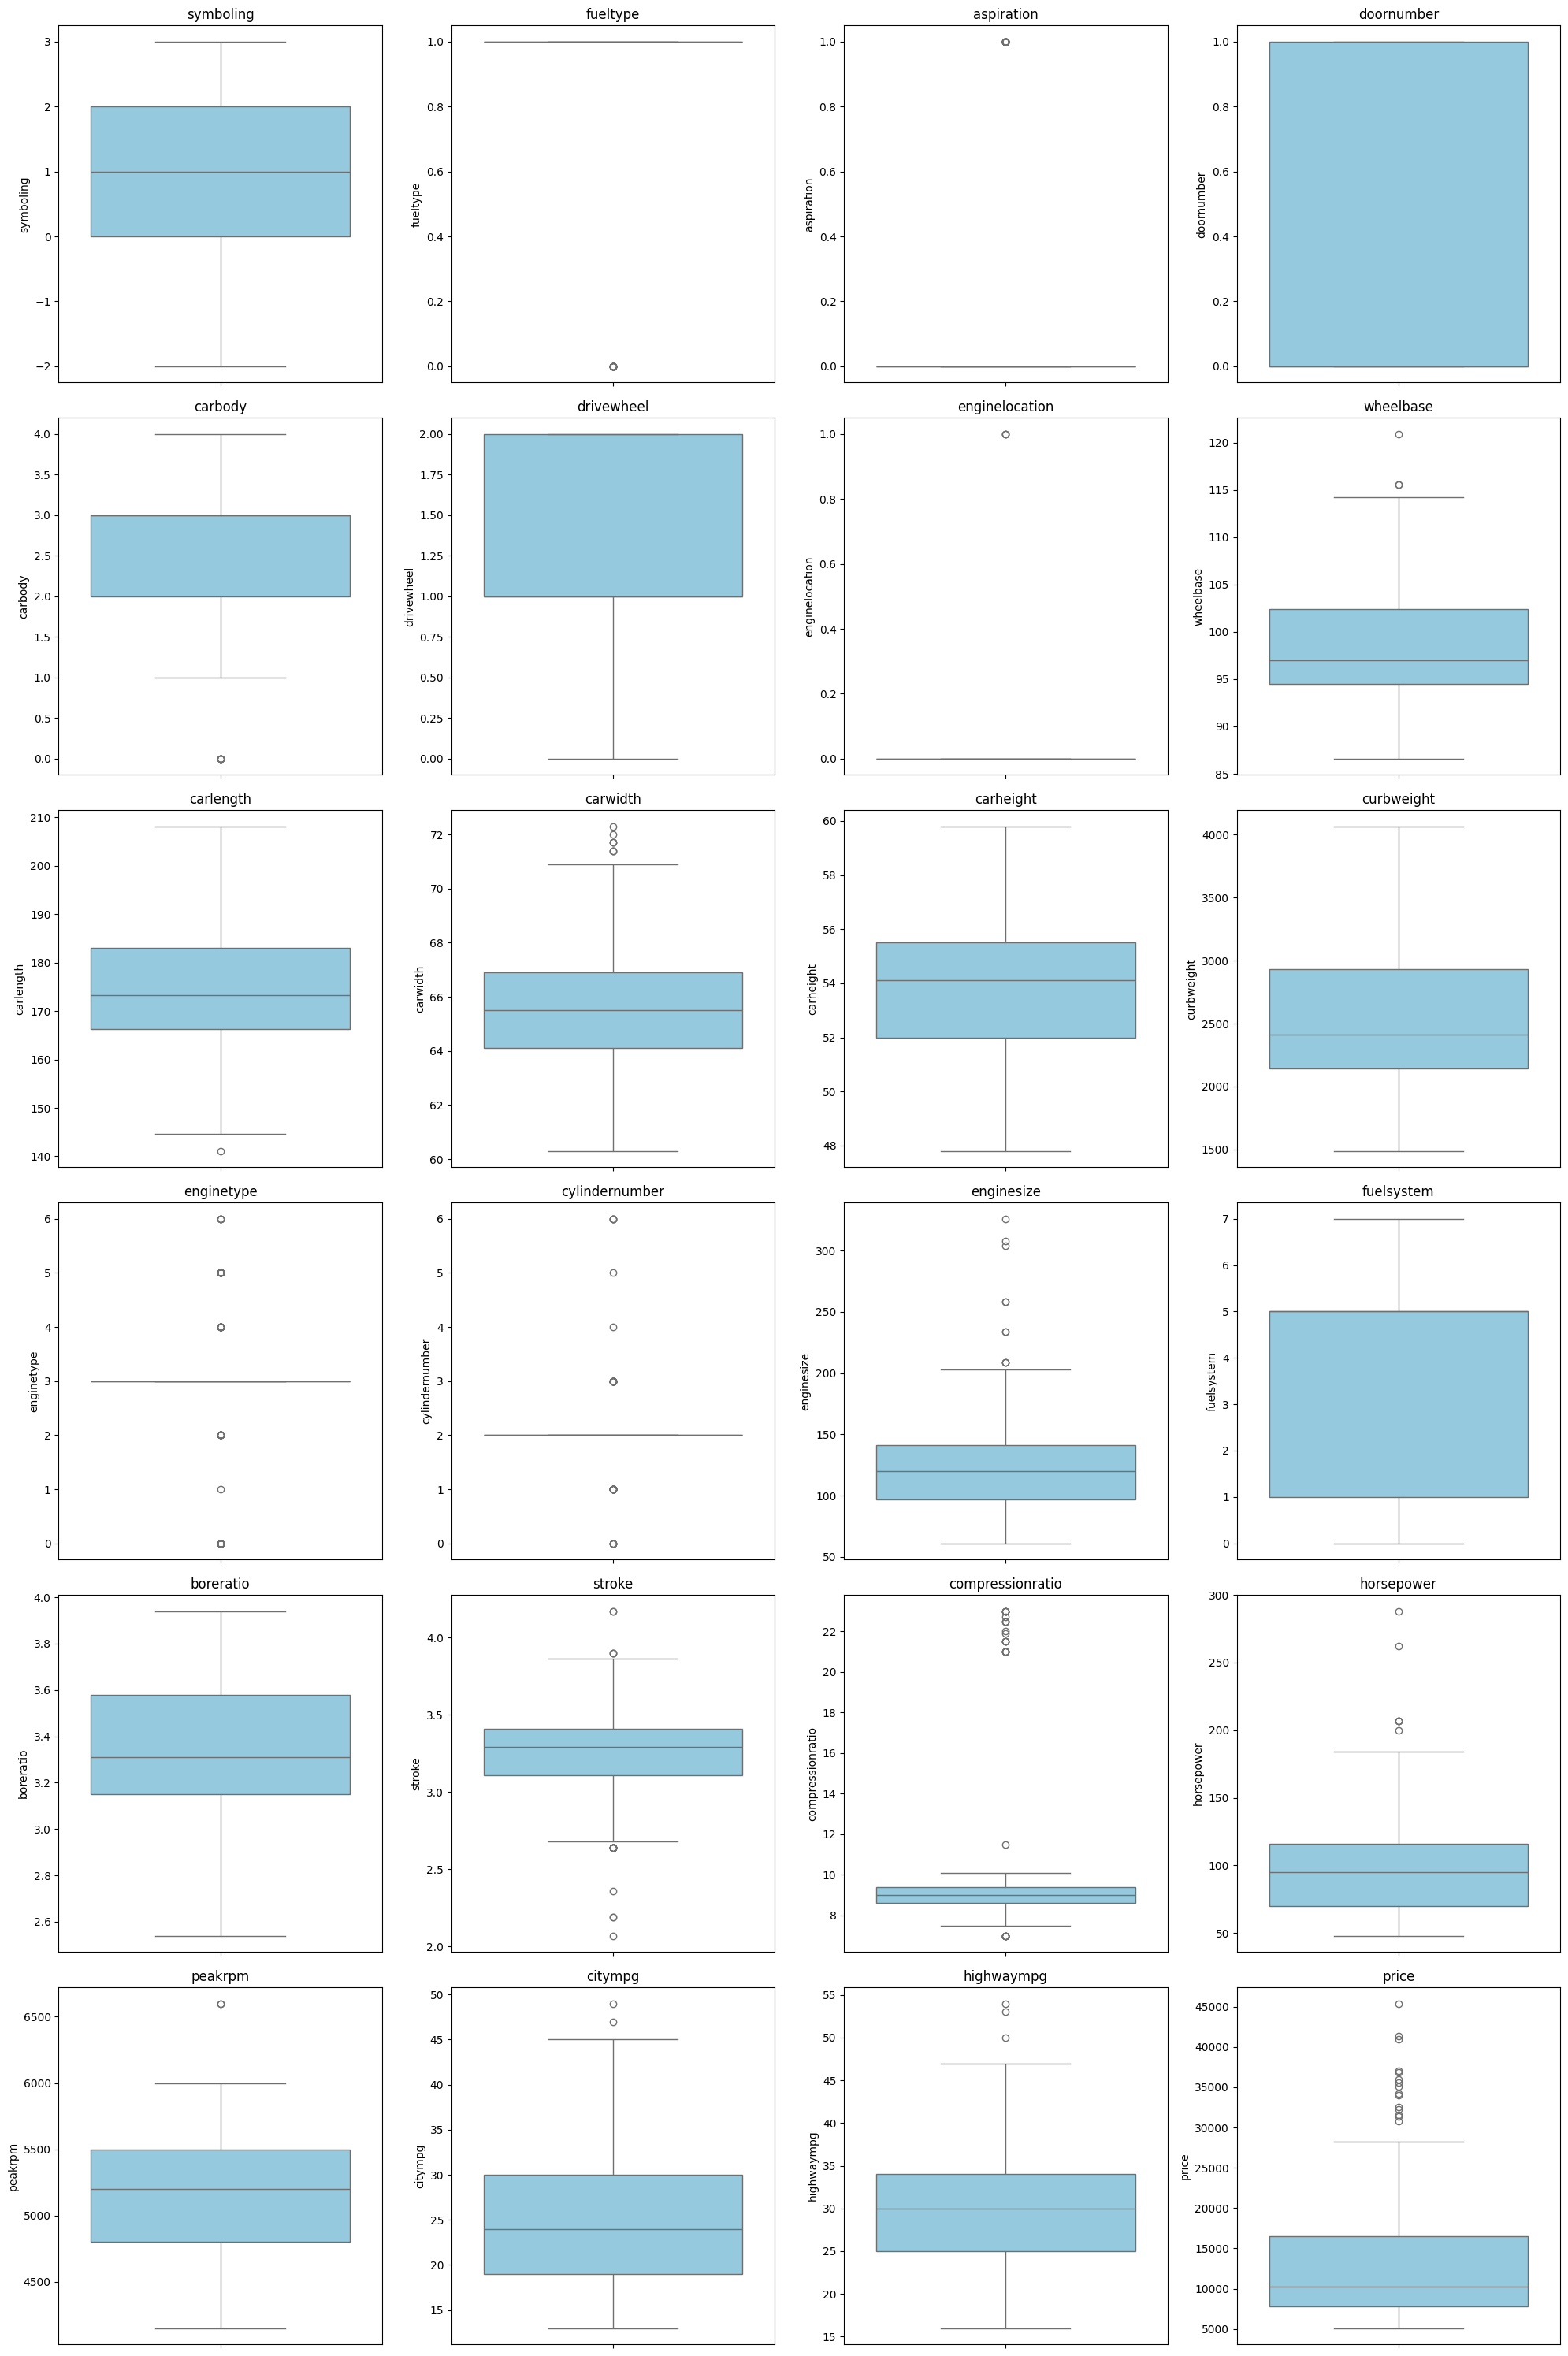

In [157]:
import math

num_cols = df.select_dtypes(include=np.number).columns
n = len(num_cols)
rows = math.ceil(n / 4)
plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()


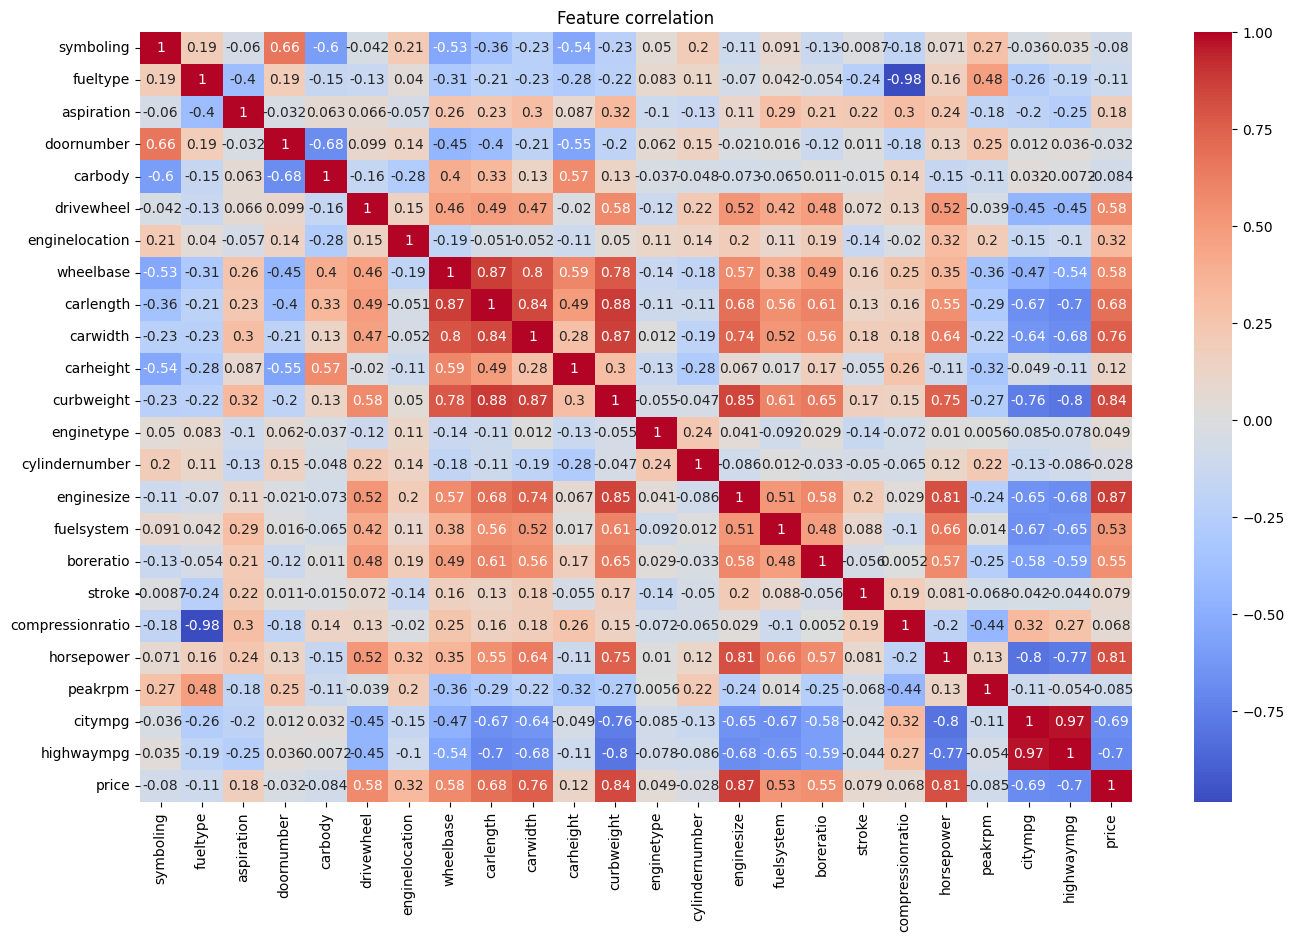

In [158]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

In [159]:
X=df.iloc[:,:-1]
X.head()
Y=df.loc[:,'price']

🔹 Training MSE: 6170935.555113514
🔹 Testing MSE: 15916389.725439383
🔹 Training R²: 0.8965265035488763
🔹 Testing R²: 0.7983838478445082


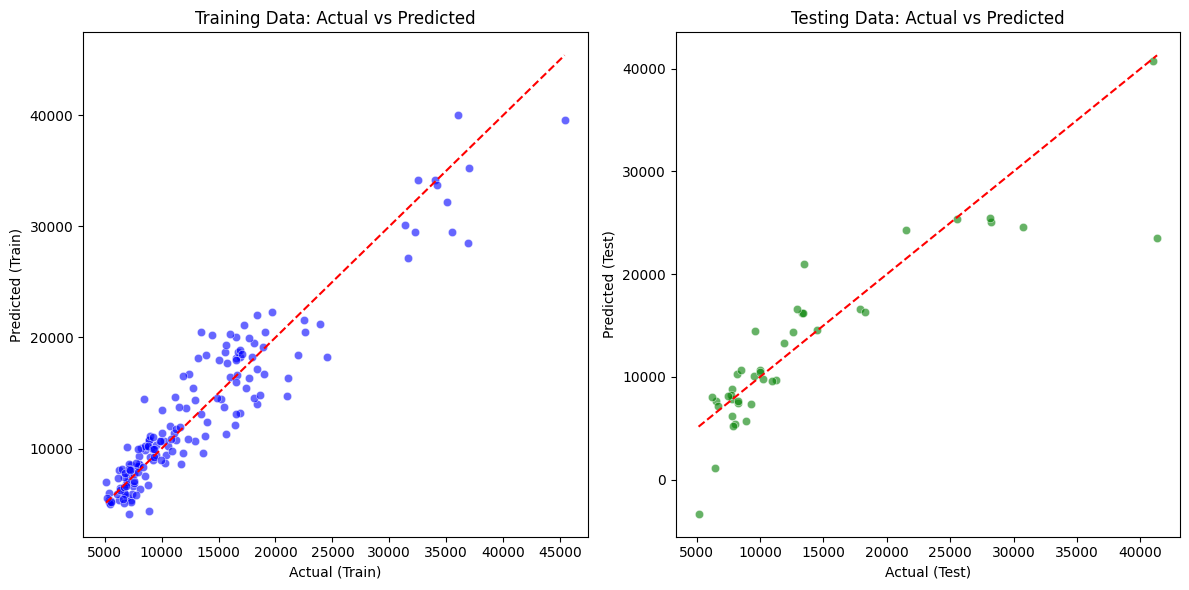

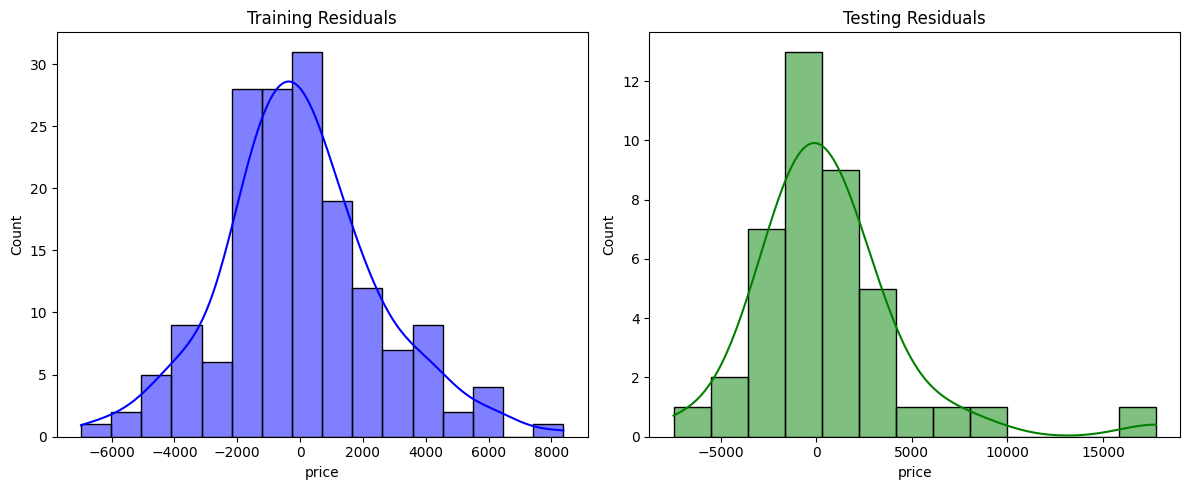

In [ ]:
LR = LinearRegression()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
ModelLR = LR.fit(X_train, Y_train)

Y_train_pred = ModelLR.predict(X_train)
Y_test_pred = ModelLR.predict(X_test)

train_mse = mean_squared_error(Y_train, Y_train_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
train_r2 = r2_score(Y_train, Y_train_pred)
test_r2 = r2_score(Y_test, Y_test_pred)

print("🔹 Training MSE:", train_mse)
print("🔹 Testing MSE:", test_mse)
print("🔹 Training R²:", train_r2)
print("🔹 Testing R²:", test_r2)

plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=Y_train, y=Y_train_pred, color='blue', alpha=0.6)
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("Training Data: Actual vs Predicted")

plt.subplot(1, 2, 2)
sns.scatterplot(x=Y_test, y=Y_test_pred, color='green', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel("Actual (Test)")
plt.ylabel("Predicted (Test)")
plt.title("Testing Data: Actual vs Predicted")

plt.tight_layout()
plt.show()

train_residuals = Y_train - Y_train_pred
test_residuals = Y_test - Y_test_pred

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(train_residuals, kde=True, color='blue')
plt.title("Training Residuals")

plt.subplot(1, 2, 2)
sns.histplot(test_residuals, kde=True, color='green')
plt.title("Testing Residuals")

plt.tight_layout()
plt.show()

In [161]:
!pip install statsmodels

'pip' is not recognized as an internal or external command,
operable program or batch file.


✅ Data loaded successfully
   Fan  Refrigerator  AirConditioner  Television  Monitor  MotorPump  Month  \
0   16          23.0             2.0         6.0      1.0          0     10   
1   19          22.0             2.0         3.0      1.0          0      5   
2    7          20.0             2.0         6.0      7.0          0      7   
3    7          22.0             3.0        21.0      1.0          0      6   
4   11          23.0             2.0        11.0      1.0          0      2   

        City                                    Company  MonthlyHours  \
0  Hyderabad                    Tata Power Company Ltd.           384   
1   Vadodara                                       NHPC           488   
2     Shimla                            Jyoti Structure           416   
3     Mumbai                            Power Grid Corp           475   
4     Mumbai  Ratnagiri Gas and Power Pvt. Ltd. (RGPPL)           457   

   TariffRate  ElectricityBill  
0         8.4           32

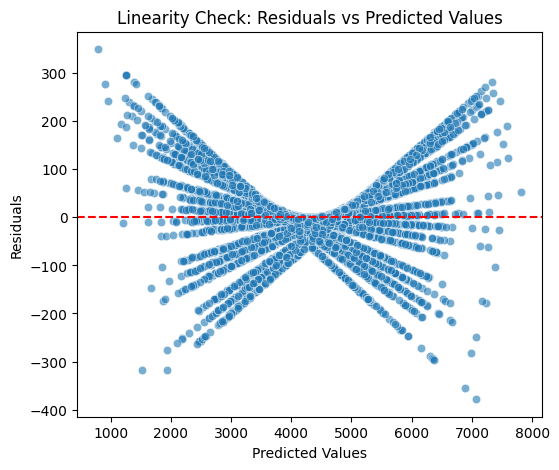

👉 If points are randomly scattered around 0, linearity holds.



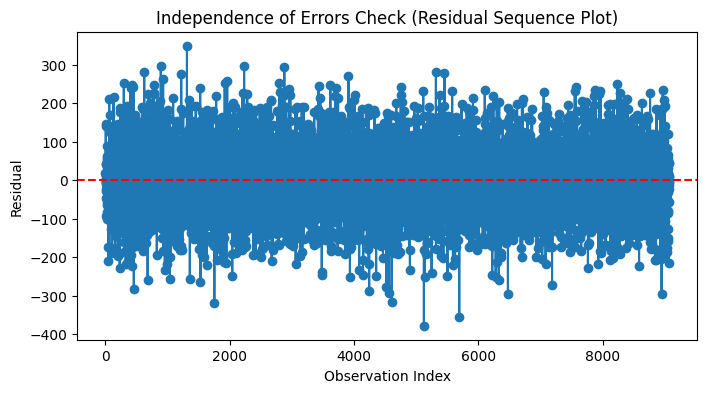

👉 If residuals are randomly distributed (no clear trend), independence likely holds.



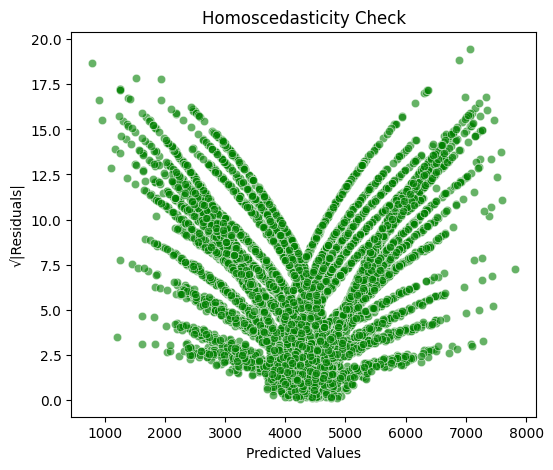

👉 Constant spread indicates homoscedasticity. Funnel shape indicates heteroscedasticity.



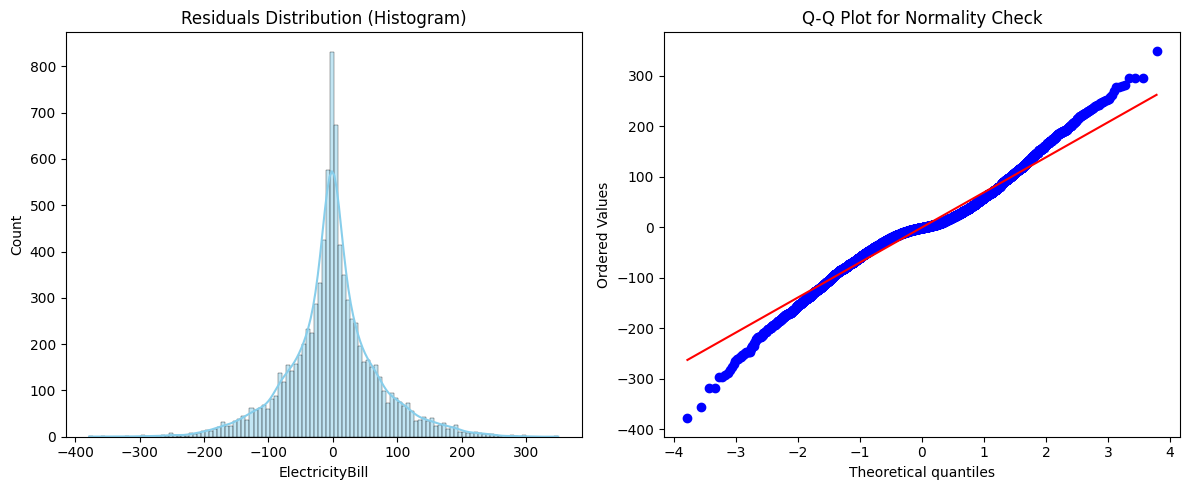

c:\Users\LAPTOOL TECHNOLOGY\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9069.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk test p-value: 0.0000
⚠️ Residuals not normal (reject H0).



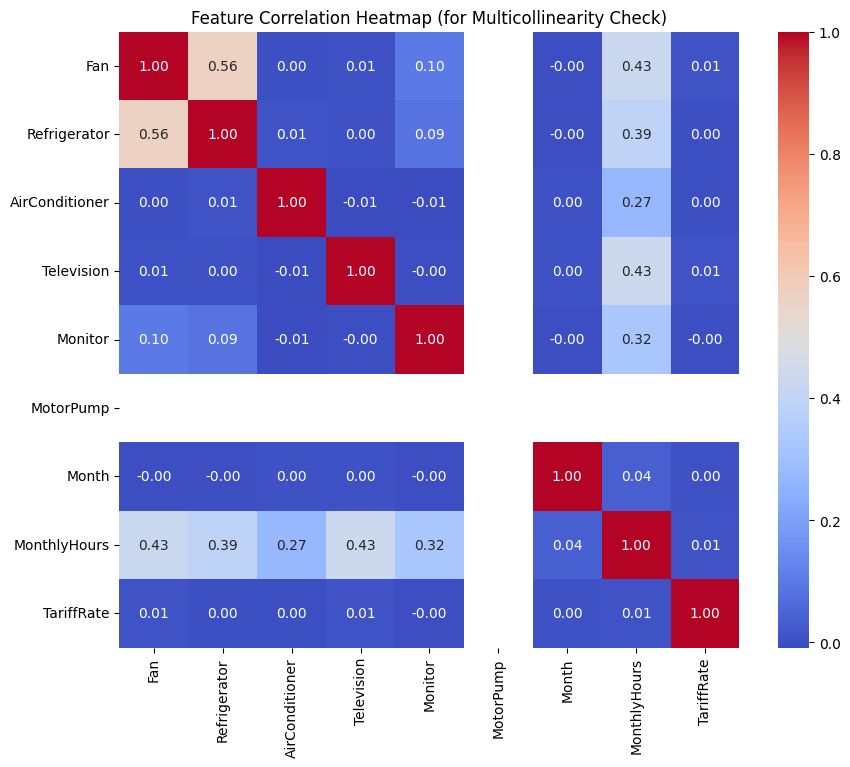

Highly correlated features (|r| > 0.8):

Model Performance:
Mean Squared Error (MSE): 4969.728
R² Score: 0.996

✅ Assumption check completed successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import probplot, shapiro


df = pd.read_csv("electricity_bill_dataset.csv")  
print("✅ Data loaded successfully")
print(df.head())
df.drop('City',axis=1,inplace=True)
df.drop('Company',axis=1,inplace=True)

X = df.drop('ElectricityBill', axis=1)
Y = df['ElectricityBill']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)
residuals = Y_test - Y_test_pred

plt.figure(figsize=(6,5))
sns.scatterplot(x=Y_test_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Linearity Check: Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()
print("👉 If points are randomly scattered around 0, linearity holds.\n")


plt.figure(figsize=(8,4))
plt.plot(residuals.values, marker='o')
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Independence of Errors Check (Residual Sequence Plot)")
plt.xlabel("Observation Index")
plt.ylabel("Residual")
plt.show()
print("👉 If residuals are randomly distributed (no clear trend), independence likely holds.\n")

plt.figure(figsize=(6,5))
sns.scatterplot(x=Y_test_pred, y=np.sqrt(np.abs(residuals)), alpha=0.6, color='green')
plt.title("Homoscedasticity Check")
plt.xlabel("Predicted Values")
plt.ylabel("√|Residuals|")
plt.show()
print("👉 Constant spread indicates homoscedasticity. Funnel shape indicates heteroscedasticity.\n")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='skyblue')
plt.title("Residuals Distribution (Histogram)")

plt.subplot(1, 2, 2)
probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot for Normality Check")
plt.tight_layout()
plt.show()

stat, p = shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {p:.4f}")
if p > 0.05:
    print("✅ Residuals likely normal (fail to reject H0).")
else:
    print("⚠️ Residuals not normal (reject H0).")
print()


corr_matrix = X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (for Multicollinearity Check)")
plt.show()


high_corr = [(col, corr_matrix[col][corr_matrix[col].abs() > 0.8].index.tolist())
             for col in corr_matrix.columns]
print("Highly correlated features (|r| > 0.8):")
for col, correlated in high_corr:
    if len(correlated) > 1:
        print(f"🔸 {col}: {correlated}")
print()

mse = mean_squared_error(Y_test, Y_test_pred)
r2 = r2_score(Y_test, Y_test_pred)
print("Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R² Score: {r2:.3f}")
print("\n✅ Assumption check completed successfully.")
